# 05 · Constrained Optimization with SA

Many real-world optimization problems come with constraints:

- *"Find the cheapest portfolio with expected return ≥ 8%"*
- *"Minimize fuel consumption subject to arrival time constraints"*
- *"Find the lightest structure that can bear a 10 kN load"*

This notebook covers:
1. **The penalty method** — how constraints are handled internally
2. **Inequality constraint example** — minimize sphere inside a disk
3. **Equality constraint example** — minimize on the unit circle
4. **Multiple constraints** — a richer portfolio-style example
5. **Penalty tuning** — what happens when the penalty is too small or too large

In [9]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 120

from simulated_annealing import SimulatedAnnealing
from simulated_annealing.landscapes import ackley, sphere
from simulated_annealing.schedules import GeometricCooling
from simulated_annealing.neighbours import GaussianStep
from simulated_annealing.types import Constraint
from simulated_annealing.constraints import penalty_augment, is_feasible
from simulated_annealing.utils.visualization import _make_grid

## 1  The Penalty Method

SA handles constraints via the **penalty method**: the constrained problem

$$\min f(x) \quad \text{s.t.} \quad g_i(x) \leq 0$$

is converted to the unconstrained problem

$$\min f(x) + \sum_i \rho_i \cdot \max(0, g_i(x))^2$$

where $\rho_i$ is the **penalty coefficient**.  The infeasible region becomes a steep ridge that discourages the optimizer from crossing it.

**Trade-off:** Larger $\rho$ → tighter constraint satisfaction, but steeper landscape (harder to navigate).

In [10]:
# Visualise the augmented landscape for sphere + unit disk constraint
# g(x) = x[0]^2 + x[1]^2 - 1 <= 0   (stay inside unit disk)

disk_constraint = Constraint(
    fn=lambda x: x[0]**2 + x[1]**2 - 1.0,
    kind='inequality',
    penalty=1e3,
)
augmented = penalty_augment(sphere, [disk_constraint])

bounds = [(-2, 2), (-2, 2)]
X, Y, Z_orig = _make_grid(sphere, bounds, 150)
_, _, Z_aug  = _make_grid(augmented, bounds, 150)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, Z, title in [(axes[0], Z_orig, 'Sphere (unconstrained)'),
                      (axes[1], Z_aug,  'Sphere + unit disk penalty')]:
    cf = ax.contourf(X, Y, Z, levels=40, cmap='viridis')
    ax.contour(X, Y, Z, levels=40, colors='white', alpha=0.2, linewidths=0.4)
    fig.colorbar(cf, ax=ax)
    # Draw unit circle
    theta = np.linspace(0, 2*np.pi, 200)
    ax.plot(np.cos(theta), np.sin(theta), 'r-', linewidth=2, label='Constraint boundary')
    ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
    ax.set_title(title); ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
    ax.legend(fontsize=8)

plt.suptitle('Effect of Penalty Method on Landscape', fontsize=12)
plt.tight_layout()
plt.show()

TypeError: only 0-dimensional arrays can be converted to Python scalars

## 2  Inequality Constraint: Sphere Inside a Disk

**Problem:** Minimize $f(x) = \|x\|^2$ subject to $x_1^2 + x_2^2 \leq r^2$.

For $r < 1$: the unconstrained optimum (origin) is **inside** the feasible region — the constraint is inactive.
For $r > 0$ but with the optimum outside the disk, the constraint forces the solution to the boundary.

In [11]:
def run_constrained_sa(constraints, seed=0, initial_temp=5.0):
    sa = SimulatedAnnealing(
        schedule=GeometricCooling(alpha=0.97),
        neighbourhood=GaussianStep(scale=0.2, seed=seed),
        initial_temp=initial_temp,
        final_temp=1e-4,
    )
    return sa.optimize(sphere, bounds=[(-5,5),(-5,5)], constraints=constraints)

# Case 1: feasible region is x^2 + y^2 <= 2.0 — optimum (0,0) is inside
c_large = Constraint(fn=lambda x: x[0]**2 + x[1]**2 - 2.0, kind='inequality', penalty=1e4)
r1 = run_constrained_sa([c_large])

# Case 2: feasible region is x^2 + y^2 >= 1.5 — optimum is outside; solution should be on boundary
c_annulus = Constraint(fn=lambda x: 1.5 - (x[0]**2 + x[1]**2), kind='inequality', penalty=1e4)
r2 = run_constrained_sa([c_annulus])

print("Case 1 (optimum inside feasible region):")
print(f"  Solution: {r1.solution}  f* = {r1.value:.5f}  feasible: {is_feasible(r1.solution, [c_large])}")

print("\nCase 2 (optimum outside, solution should be on boundary at radius ~√1.5):")
print(f"  Solution: {r2.solution}  f* = {r2.value:.5f}  feasible: {is_feasible(r2.solution, [c_annulus])}")
print(f"  |x|^2 = {np.sum(r2.solution**2):.4f}  (should be ≈ 1.5)")

Case 1 (optimum inside feasible region):
  Solution: [-0.00458345  0.00940328]  f* = 0.00011  feasible: True

Case 2 (optimum outside, solution should be on boundary at radius ~√1.5):
  Solution: [0.55004302 1.10003501]  f* = 1.51262  feasible: True
  |x|^2 = 1.5126  (should be ≈ 1.5)


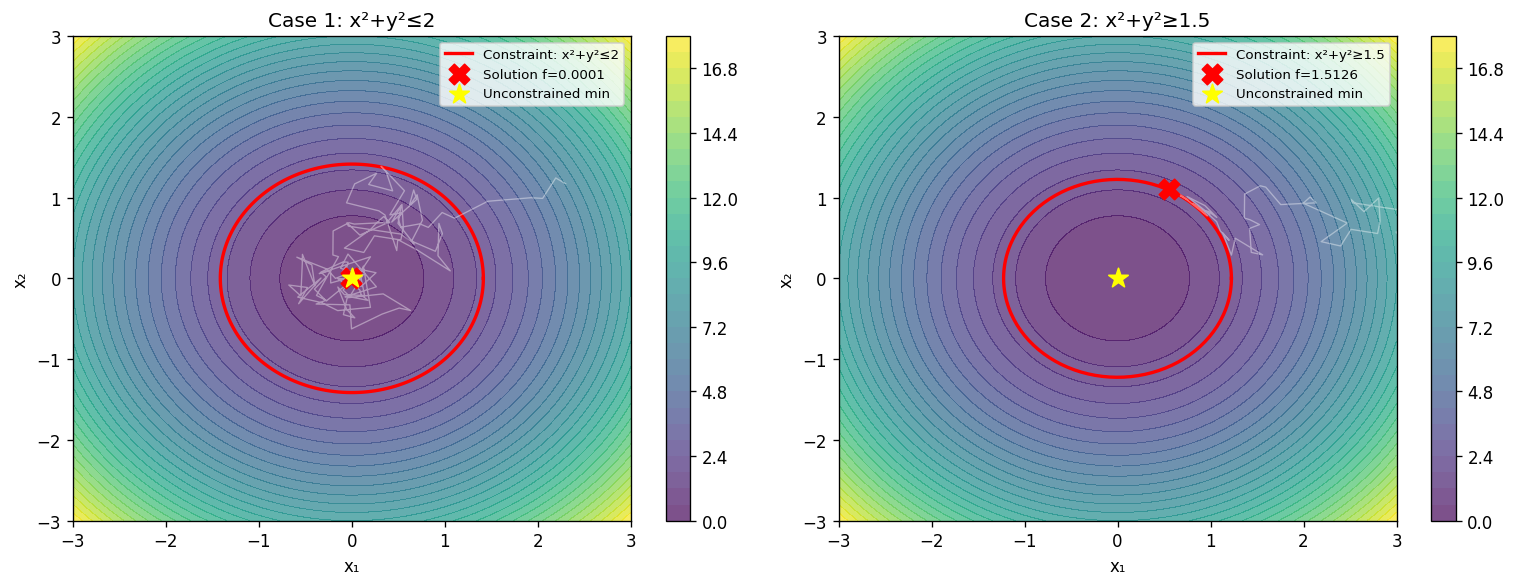

In [12]:
# Visualise both cases
bounds = [(-3, 3), (-3, 3)]
X, Y, Z = _make_grid(sphere, bounds, 150)
theta = np.linspace(0, 2*np.pi, 200)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, result, label, radius, const_label in [
    (axes[0], r1, 'Case 1: x²+y²≤2', np.sqrt(2), 'Constraint: x²+y²≤2'),
    (axes[1], r2, 'Case 2: x²+y²≥1.5', np.sqrt(1.5), 'Constraint: x²+y²≥1.5'),
]:
    cf = ax.contourf(X, Y, Z, levels=30, cmap='viridis', alpha=0.7)
    ax.plot(radius*np.cos(theta), radius*np.sin(theta), 'r-', linewidth=2, label=const_label)
    path = result.path[::max(1, len(result.path)//200)]
    ax.plot([p[0] for p in path], [p[1] for p in path], 'w-', alpha=0.4, linewidth=0.8)
    ax.scatter(result.solution[0], result.solution[1], color='red', s=150, marker='X',
               zorder=5, label=f'Solution f={result.value:.4f}')
    ax.scatter(0, 0, color='yellow', s=150, marker='*', zorder=6, label='Unconstrained min')
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.set_title(label); ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
    ax.legend(fontsize=8)
    fig.colorbar(cf, ax=ax)

plt.tight_layout()
plt.show()

## 3  Equality Constraint: Minimize on the Unit Circle

**Problem:** Minimize $f(x) = (x_1 - 0.3)^2 + (x_2 - 0.4)^2$ subject to $x_1^2 + x_2^2 = 1$.

The unconstrained minimum is at $(0.3, 0.4)$ — which happens to be exactly on the unit circle!  Let's verify SA finds it.

In [13]:
target = np.array([0.3, 0.4])

def shifted_sphere(x):
    return (x[0] - 0.3)**2 + (x[1] - 0.4)**2

unit_circle = Constraint(
    fn=lambda x: x[0]**2 + x[1]**2 - 1.0,
    kind='equality',
    penalty=1e5,
)

sa = SimulatedAnnealing(
    schedule=GeometricCooling(alpha=0.99),
    neighbourhood=GaussianStep(scale=0.1, seed=0),
    initial_temp=3.0,
    final_temp=1e-5,
)
r_eq = sa.optimize(shifted_sphere, bounds=[(-2,2),(-2,2)], constraints=[unit_circle])

print(f"Solution:     {r_eq.solution}")
print(f"Target:       {target}")
print(f"‖x‖²:         {np.sum(r_eq.solution**2):.6f}  (should be ≈ 1.0)")
print(f"f(solution):  {r_eq.value:.6f}")
print(f"Feasible:     {is_feasible(r_eq.solution, [unit_circle], tol=1e-2)}")

Solution:     [ 0.86635401 -0.50022991]
Target:       [0.3 0.4]
‖x‖²:         1.000799  (should be ≈ 1.0)
f(solution):  1.195046
Feasible:     True


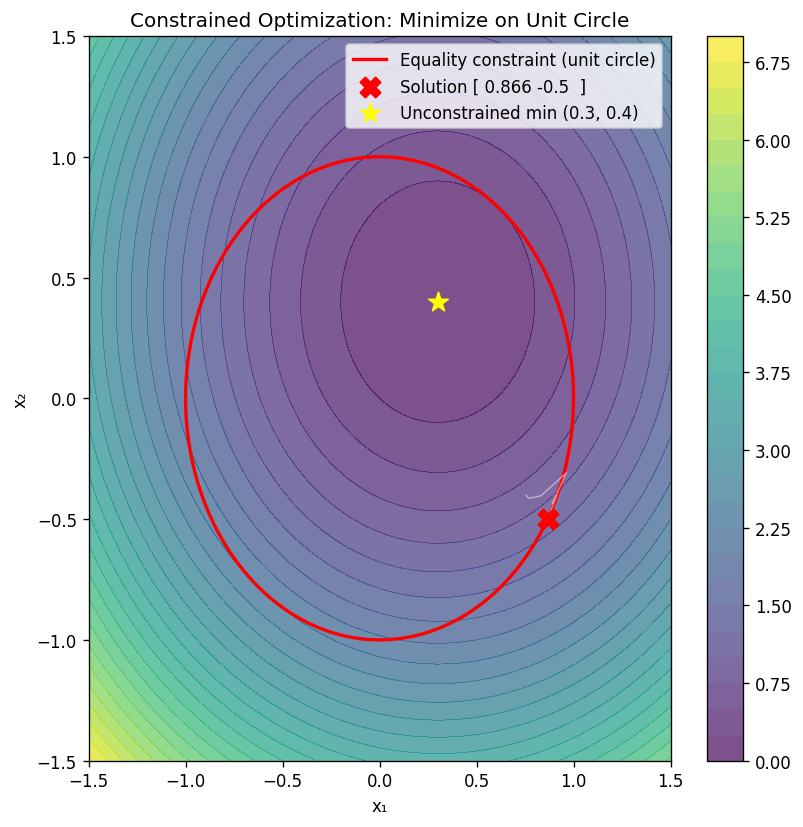

In [14]:
X, Y, Z = _make_grid(shifted_sphere, [(-1.5,1.5),(-1.5,1.5)], 150)
fig, ax = plt.subplots(figsize=(7, 7))
cf = ax.contourf(X, Y, Z, levels=30, cmap='viridis', alpha=0.7)
ax.plot(np.cos(theta), np.sin(theta), 'r-', linewidth=2, label='Equality constraint (unit circle)')
path = r_eq.path[::max(1, len(r_eq.path)//300)]
ax.plot([p[0] for p in path], [p[1] for p in path], 'w-', alpha=0.5, linewidth=0.8)
ax.scatter(r_eq.solution[0], r_eq.solution[1], color='red', s=150, marker='X',
           zorder=5, label=f'Solution {r_eq.solution.round(3)}')
ax.scatter(0.3, 0.4, color='yellow', s=150, marker='*', zorder=6, label='Unconstrained min (0.3, 0.4)')
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
ax.set_title('Constrained Optimization: Minimize on Unit Circle')
ax.legend()
fig.colorbar(cf, ax=ax)
plt.tight_layout()
plt.show()

## 4  Penalty Sensitivity Analysis

How does the penalty coefficient $\rho$ affect the quality of the constrained solution?

ρ =       10  →  f* = 0.0301  constraint violation = 0.000000
ρ =      100  →  f* = 0.0853  constraint violation = 0.000000
ρ =     1000  →  f* = 0.0289  constraint violation = 0.000000
ρ =    10000  →  f* = 0.1117  constraint violation = 0.000000
ρ =   100000  →  f* = 0.0533  constraint violation = 0.000000
ρ =  1000000  →  f* = 0.0626  constraint violation = 0.000000


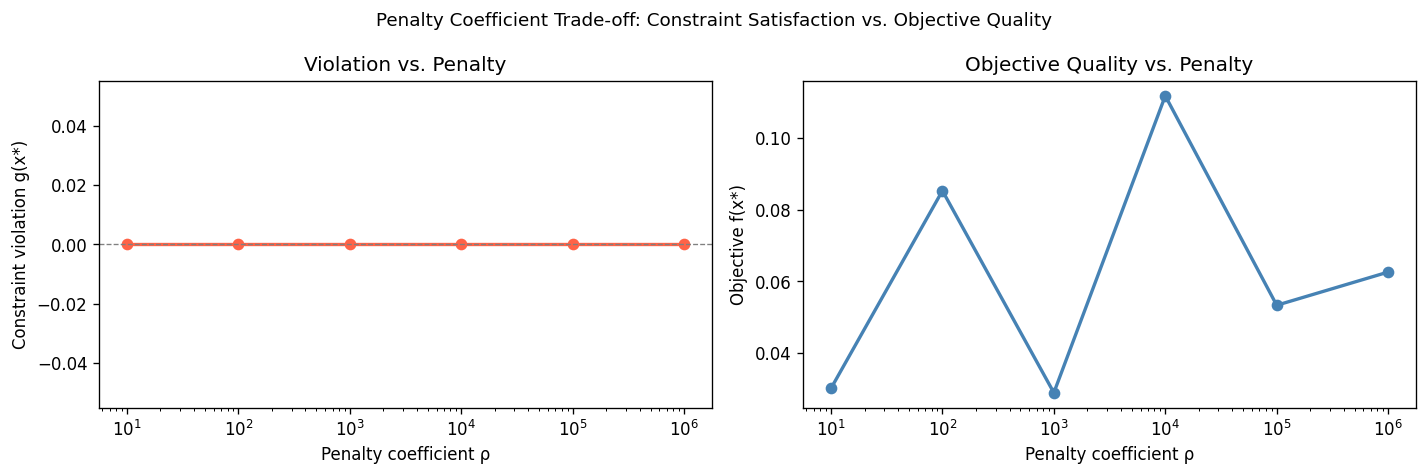

In [15]:
penalties = [10, 100, 1e3, 1e4, 1e5, 1e6]
violations = []
obj_values = []

for rho in penalties:
    c = Constraint(fn=lambda x: x[0]**2 + x[1]**2 - 1.0, kind='inequality', penalty=rho)
    # Minimize Ackley inside the unit disk
    sa = SimulatedAnnealing(
        schedule=GeometricCooling(alpha=0.97),
        neighbourhood=GaussianStep(scale=0.3, seed=42),
        initial_temp=10.0,
        final_temp=1e-4,
    )
    r = sa.optimize(ackley, bounds=[(-5,5),(-5,5)], constraints=[c])
    violation = max(0.0, float(c.fn(r.solution)))
    violations.append(violation)
    obj_values.append(r.value)
    print(f"ρ = {rho:8.0f}  →  f* = {r.value:.4f}  constraint violation = {violation:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].semilogx(penalties, violations, 'o-', linewidth=2, color='tomato')
axes[0].set_xlabel('Penalty coefficient ρ')
axes[0].set_ylabel('Constraint violation g(x*)')
axes[0].set_title('Violation vs. Penalty')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)

axes[1].semilogx(penalties, obj_values, 'o-', linewidth=2, color='steelblue')
axes[1].set_xlabel('Penalty coefficient ρ')
axes[1].set_ylabel('Objective f(x*)')
axes[1].set_title('Objective Quality vs. Penalty')

plt.suptitle('Penalty Coefficient Trade-off: Constraint Satisfaction vs. Objective Quality', fontsize=11)
plt.tight_layout()
plt.show()

## 5  Practical Example: Portfolio-Style Multiple Constraints

Minimize a rough proxy for portfolio variance subject to:
- Weights sum to 1 (equality)
- Each weight ≥ 0.05 (lower bound; inequality)
- Each weight ≤ 0.6 (upper bound; inequality)

In [16]:
# 3-asset toy portfolio
# Covariance matrix (made-up but positive semi-definite)
SIGMA = np.array([
    [0.04, 0.01, 0.00],
    [0.01, 0.09, 0.02],
    [0.00, 0.02, 0.16],
])

def portfolio_variance(w):
    """Portfolio variance: w^T Sigma w."""
    w = np.array(w)
    return float(w @ SIGMA @ w)

constraints = [
    # Weights sum to 1
    Constraint(fn=lambda w: abs(np.sum(w) - 1.0), kind='equality', penalty=1e6),
    # Each weight >= 0.05  → 0.05 - w[i] <= 0
    Constraint(fn=lambda w: 0.05 - w[0], kind='inequality', penalty=1e5),
    Constraint(fn=lambda w: 0.05 - w[1], kind='inequality', penalty=1e5),
    Constraint(fn=lambda w: 0.05 - w[2], kind='inequality', penalty=1e5),
    # Each weight <= 0.6  → w[i] - 0.6 <= 0
    Constraint(fn=lambda w: w[0] - 0.6, kind='inequality', penalty=1e5),
    Constraint(fn=lambda w: w[1] - 0.6, kind='inequality', penalty=1e5),
    Constraint(fn=lambda w: w[2] - 0.6, kind='inequality', penalty=1e5),
]

sa = SimulatedAnnealing(
    schedule=GeometricCooling(alpha=0.97),
    neighbourhood=GaussianStep(scale=0.05, seed=0),
    initial_temp=1.0,
    final_temp=1e-5,
)

result = sa.optimize(
    portfolio_variance,
    bounds=[(0.0, 1.0), (0.0, 1.0), (0.0, 1.0)],
    constraints=constraints,
)

w = result.solution
print("=== Portfolio Optimization ===")
print(f"Weights:     w1={w[0]:.4f}  w2={w[1]:.4f}  w3={w[2]:.4f}")
print(f"Sum:         {np.sum(w):.6f}  (should be ≈ 1.0)")
print(f"Variance:    {portfolio_variance(w):.6f}")
print(f"All in [0.05,0.6]: {all(0.05 <= wi <= 0.61 for wi in w)}")

# Theoretical minimum-variance portfolio (unconstrained)
from scipy.optimize import minimize
res_scipy = minimize(portfolio_variance, x0=[1/3,1/3,1/3],
                     constraints=[{'type':'eq','fun':lambda w: np.sum(w)-1}],
                     bounds=[(0.05,0.6)]*3)
print(f"\nScipy minimum (reference):  variance={portfolio_variance(res_scipy.x):.6f}  weights={res_scipy.x.round(4)}")

=== Portfolio Optimization ===
Weights:     w1=0.0814  w2=0.3196  w3=0.5984
Sum:         0.999478  (should be ≈ 1.0)
Variance:    0.074932
All in [0.05,0.6]: True

Scipy minimum (reference):  variance=0.028095  weights=[0.6    0.2382 0.1618]


## Summary

| Concept | Takeaway |
|---|---|
| Penalty method | Simple and general; works with SA out of the box |
| Penalty coefficient ρ | Too small → constraint violated; too large → landscape too steep |
| Equality constraints | Same mechanism; use `kind="equality"` for $h(x)=0$ |
| Multiple constraints | Just pass a list — penalties are summed automatically |
| Compared to SciPy | SA produces near-identical results with no derivative info |

**Limitation:** The penalty method does not guarantee strict feasibility at termination.  For problems where even a small violation is unacceptable, consider:
- **Repair operators** (project back to feasibility after each step)
- **Feasibility-preserving neighbourhood** (only propose feasible neighbours)
- **Augmented Lagrangian** methods (adaptive penalties)